<a href="https://colab.research.google.com/github/whtan88/RandomDataAnalyst_DataAnalysis/blob/main/t_SNE_vs_UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "marmara2.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aiwithcagri/marmara-sea-fish-species-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_2703/101587471.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 58.1k/58.1k [00:00<00:00, 7.78MB/s]


,total_length_cm,body_depth_cm,body_width_cm,head_length_cm,eye_diameter_mm,weight_gr,species
0,7.9,1.2,0.5,1.9,2.2,3.2,Hamsi
1,13.7,2.1,1.0,2.9,3.4,15.0,Hamsi
2,18.5,3.8,1.9,4.4,4.9,47.9,Sardalya
3,12.1,2.3,1.1,3.0,3.7,15.7,İstavrit
4,7.6,1.4,0.6,1.8,1.9,3.5,İstavrit


In [ ]:
# Inspect description of various species

df.groupby('species').describe()

total_length_cm                                                     \
                   count       mean        std   min     25%    50%     75%   
species                                                                       
Hamsi              500.0  11.500400   3.161555   4.5   8.300  12.40  14.100   
Kalkan              30.0  48.106667  18.795853  14.5  29.075  54.40  62.000   
Lüfer               80.0  27.051250   8.224816  10.7  20.050  29.00  34.075   
Mezgit             150.0  18.936000   7.271783   6.6  11.725  20.80  25.200   
Palamut            120.0  41.662500  13.019908  17.6  28.075  45.25  52.125   
Sardalya           300.0  14.064000   4.019048   6.0  10.175  15.45  17.200   
Tekir              100.0  16.156000   5.185047   6.4  10.575  17.55  19.900   
Zargana             50.0  45.510000  13.525143  18.7  39.225  49.65  54.650   
İstavrit           350.0  16.026857   4.147291   7.4  12.100  17.30  19.400   
İzmarit             80.0  15.396250   4.611802   6.5  10.900  16.80  19.000   

               body_depth_cm             ... eye_diameter_mm       weight_gr  \
           max         count       mean  ...             75%   max     count   
species                                  ...                                   
Hamsi     17.7         500.0   1.660800  ...           3.600   4.7     500.0   
Kalkan    76.5          30.0  38.300000  ...          10.175  14.1      30.0   
Lüfer     44.7          80.0   6.210000  ...           8.525  10.6      80.0   
Mezgit    34.3         150.0   3.521333  ...           8.000  10.3     150.0   
Palamut   66.0         120.0   9.710000  ...          10.800  13.8     120.0   
Sardalya  21.3         300.0   2.823333  ...           4.800   6.1     300.0   
Tekir     26.0         100.0   3.869000  ...           5.300   6.8     100.0   
Zargana   66.9          50.0   2.256000  ...          12.500  15.1      50.0   
İstavrit  23.0         350.0   3.349714  ...           6.000   8.6     350.0   
İzmarit   23.2          80.0   4.681250  ...           5.700   7.5      80.0   

                                                                               
                 mean          std   min      25%      50%       75%      max  
species                                                                        
Hamsi       11.315600     7.819276   0.5    3.400    11.45    16.900     37.9  
Kalkan    3448.626667  2971.027267  57.4  512.600  3230.50  5153.725  10127.5  
Lüfer      199.221250   151.055807   8.2   64.025   195.65   321.425    789.7  
Mezgit      70.498667    60.305476   2.1   11.350    63.40   118.550    243.6  
Palamut   1179.400833   871.967376  73.4  292.875  1208.05  1753.875   3810.3  
Sardalya    26.520333    19.011734   1.5    7.375    27.15    38.900     79.6  
Tekir       54.640000    40.741176   2.1   11.975    53.00    80.425    164.1  
Zargana    176.452000   123.945599   7.8   85.925   174.85   243.225    518.8  
İstavrit    40.295714    25.896147   2.9   14.900    42.60    58.900    106.5  
İzmarit     49.002500    34.872411   2.9   14.475    48.65    76.200    131.2  

[10 rows x 48 columns]

In [ ]:
# Perform Scaling on data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('species', axis=1))
scaled_data

array([[-0.88852944, -0.51612845, -0.86042288, -0.81048477, -1.03273759,
        -0.25899164],
       [-0.39139554, -0.35100737, -0.4689576 , -0.48757516, -0.54846987,
        -0.24174057],
       [ 0.02002561, -0.03911201,  0.23567989, -0.00321075,  0.05686477,
        -0.19364225],
       ...,
       [-0.63139122, -0.14919273, -0.4689576 , -0.51986613, -0.75024809,
        -0.24261774],
       [-0.85424435, -0.51612845, -0.86042288, -0.8750667 , -1.11344887,
        -0.25840686],
       [-0.16854242,  0.05262192, -0.07749233,  0.02908021, -0.02384652,
        -0.19978246]])

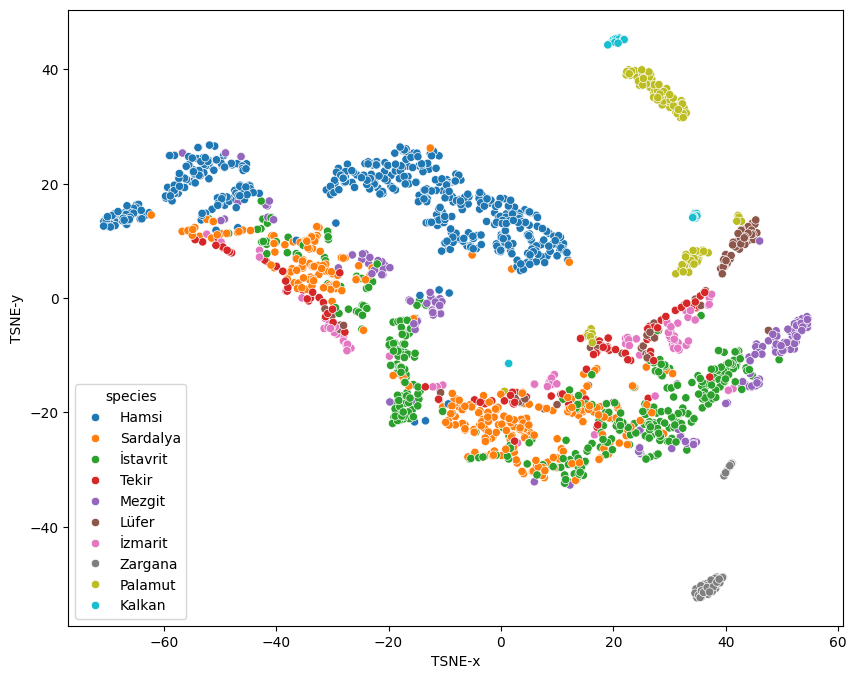

In [ ]:
# Apply T-SNE technique on scaled data and plot results

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(scaled_data)
tsne_df = pd.DataFrame(X_embedded, columns = ['TSNE-x','TSNE-y'])
tsne_df['species'] = df['species']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='TSNE-x', y='TSNE-y', hue='species')
plt.show()

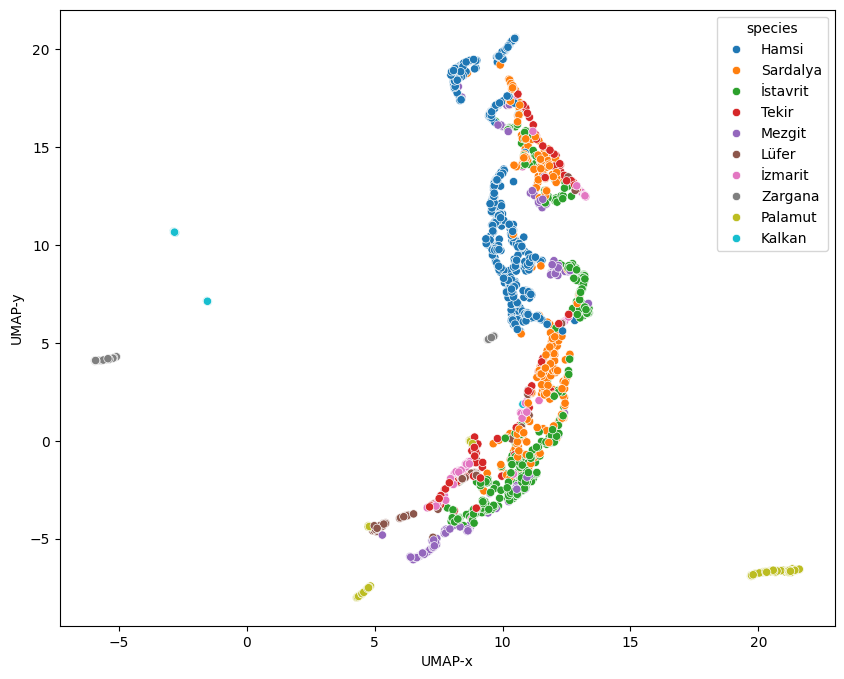

In [ ]:
# Apply UMAP technique on scaled data and plot results

reducer = umap.UMAP(n_components=2)
embedding = reducer.fit_transform(scaled_data)

umap_df = pd.DataFrame(embedding, columns = ['UMAP-x','UMAP-y'])
umap_df['species'] = df['species']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=umap_df, x='UMAP-x', y='UMAP-y', hue='species')
plt.show()